In [1]:
import sys
from pathlib import Path
import torch
from hydra import compose, initialize
from hydra.utils import instantiate
from omegaconf import OmegaConf

sys.path.insert(0, "/home/akashmanna/ws/probe3d")

In [2]:
with initialize(version_base=None, config_path="../configs"):
    cfg = compose(config_name="box3d_training")

In [3]:
model   = instantiate(cfg.backbone)
probe   = instantiate(cfg.probe, feat_dim=model.feat_dim)


/home/akashmanna/miniconda3/envs/vlg_eval312/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Using cache found in /home/akashmanna/.cache/torch/hub/facebookresearch_dinov2_main
/home/akashmanna/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/swiglu_ffn.py:51: UserWarning: xFormers is not available (SwiGLU)
  warnings.warn("xFormers is not available (SwiGLU)")
/home/akashmanna/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/attention.py:33: UserWarning: xFormers is not available (Attention)
  warnings.warn("xFormers is not available (Attention)")
/home/akashmanna/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/block.py:40: UserWarning: xFormers is not available (Block)
  warnings.warn("xFormers is not available (Block)")


In [4]:
chkpt= torch.load("/home/akashmanna/ws/probe3d/box3d_exps/02072026-1831_dinov2_vitb14_14_11_dense-cls_box3d_fcos_10_1.50_5.00e-04_0.00e+00_4_KITTI3D_KITTI3D/checkpoint.pth",
                  weights_only= False)
model.load_state_dict(chkpt["model"])
probe.load_state_dict(chkpt["probe"])

<All keys matched successfully>

In [5]:
model.eval().cuda()
probe.eval().cuda()

Box3DHead(
  (cls_convs): ModuleList(
    (0): ConvBlock(
      (0): Conv2d(1536, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (1): GroupNorm(32, 256, eps=1e-05, affine=True)
      (2): ReLU(inplace=True)
    )
    (1-3): 3 x ConvBlock(
      (0): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (1): GroupNorm(32, 256, eps=1e-05, affine=True)
      (2): ReLU(inplace=True)
    )
  )
  (reg_convs): ModuleList(
    (0): ConvBlock(
      (0): Conv2d(1536, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (1): GroupNorm(32, 256, eps=1e-05, affine=True)
      (2): ReLU(inplace=True)
    )
    (1-3): 3 x ConvBlock(
      (0): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (1): GroupNorm(32, 256, eps=1e-05, affine=True)
      (2): ReLU(inplace=True)
    )
  )
  (obj_branch): Sequential(
    (0): ConvBlock(
      (0): Conv2d(256, 128, kernel_size=(3, 3), stride=(1, 1)

In [6]:
from evals.datasets.builder import build_loader
from evals.datasets.kitti import collate_kitti

valid_loader = build_loader(cfg.dataset, "valid", batch_size=4, num_gpus=1, collate_fn=collate_kitti)
batch = next(iter(valid_loader))
print(batch["image"].shape, batch["K"].shape, [b.shape for b in batch["boxes_3d"]])

KITTI valid: 3769 images (cached)
torch.Size([4, 3, 384, 1280]) torch.Size([4, 3, 3]) [torch.Size([2, 7]), torch.Size([1, 7]), torch.Size([1, 7]), torch.Size([8, 7])]


In [7]:
def get_3d_corners(boxes):
    """boxes: (N, 7) [X, Y_bottom, Z, W, H, L, theta] -> (N, 8, 3)
    KITTI stores Y at the bottom of the box (ground plane).
    We offset by H/2 to get geometric center for correct projection."""
    x, y_bottom, z = boxes[:, 0], boxes[:, 1], boxes[:, 2]
    w, h, l = boxes[:, 3], boxes[:, 4], boxes[:, 5]
    theta = boxes[:, 6]
    y_center = y_bottom - h / 2

    corners_obj = torch.tensor([
        [-1,-1,-1],[1,-1,-1],[1,1,-1],[-1,1,-1],
        [-1,-1,1],[1,-1,1],[1,1,1],[-1,1,1]
    ], device=boxes.device, dtype=boxes.dtype)  # (8, 3)
    corners_obj = corners_obj.unsqueeze(0)  # (1, 8, 3)
    scale = torch.stack([l, h, w], dim=1) / 2  # (N, 3)
    corners_scaled = corners_obj * scale.unsqueeze(1)  # (N, 8, 3)

    cos_t, sin_t = theta.cos(), theta.sin()
    R = torch.stack([
        torch.stack([cos_t, torch.zeros_like(theta), sin_t], dim=-1),
        torch.stack([torch.zeros_like(theta), torch.ones_like(theta), torch.zeros_like(theta)], dim=-1),
        torch.stack([-sin_t, torch.zeros_like(theta), cos_t], dim=-1),
    ], dim=1)  # (N, 3, 3)

    corners = torch.bmm(corners_scaled, R.transpose(1, 2))  # (N, 8, 3)
    corners[..., 0] += x.unsqueeze(-1)
    corners[..., 1] += y_center.unsqueeze(-1)
    corners[..., 2] += z.unsqueeze(-1)
    return corners

In [8]:
import matplotlib.pyplot as plt

In [9]:
IMAGENET_MEAN = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
IMAGENET_STD  = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)

def project_2d(corners_3d, K):
    """corners: (N, 8, 3), K: (3, 3) -> (N, 8, 2)"""
    fx, fy = K[0, 0], K[1, 1]
    cx, cy = K[0, 2], K[1, 2]
    X, Y, Z = corners_3d[..., 0], corners_3d[..., 1], corners_3d[..., 2].clamp(min=1e-6)
    u = fx * X / Z + cx
    v = fy * Y / Z + cy
    return torch.stack([u, v], dim=-1)

def draw_boxes(image_tensor, gt_boxes, pred_boxes, K, figsize=(12, 4)):
    """
    image_tensor: (3, H, W) ImageNet-normalized
    gt_boxes:     (N, 7)  [X, Y_bottom, Z, W, H, L, theta]
    pred_boxes:   (M, 7)  predicted, same format
    K:            (3, 3)  intrinsics (scaled to image size)
    """
    img = image_tensor.cpu() * IMAGENET_STD + IMAGENET_MEAN
    img = img.clamp(0, 1).permute(1, 2, 0).numpy()
    edges = [(0,1),(1,2),(2,3),(3,0),(4,5),(5,6),(6,7),(7,4),(0,4),(1,5),(2,6),(3,7)]

    fig, ax = plt.subplots(figsize=figsize)
    ax.imshow(img)
    ax.set_title(f"GT (green): {len(gt_boxes)}  |  Pred (red): {len(pred_boxes)}")

    for boxes, color, label in [(gt_boxes, "lime", "GT"), (pred_boxes, "red", "Pred")]:
        if len(boxes) == 0:
            continue
        K_dev = K.to(boxes.device)
        corners_2d = project_2d(get_3d_corners(boxes), K_dev)
        for i, c in enumerate(corners_2d):
            c = c.cpu().numpy()
            for e1, e2 in edges:
                ax.plot([c[e1,0], c[e2,0]], [c[e1,1], c[e2,1]],
                        color=color, linewidth=1.0 if i == 0 else 0.8,
                        label=label if i == 0 and e1 == 0 else "")

    handles = [plt.Line2D([0],[0], color="lime", lw=2),
               plt.Line2D([0],[0], color="red", lw=2)]
    ax.legend(handles, ["GT", "Pred"])
    plt.tight_layout()
    plt.show()

In [10]:
len(batch)

5

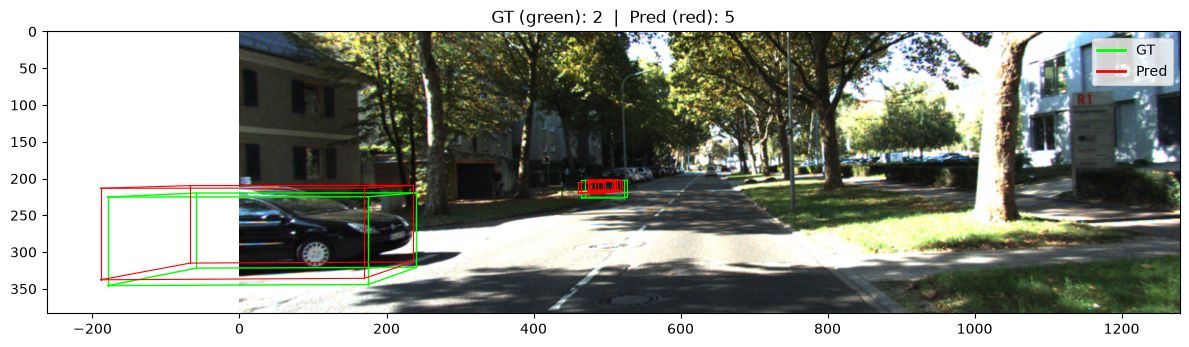

In [ ]:
# --- Run inference on one sample ---
idx = 0
image = batch["image"][idx:idx+1].cuda()           # (1, 3, H, W)
K     = batch["K"][idx].cuda()                      # (3, 3)
gt    = batch["boxes_3d"][idx].cuda()               # (N, 7)

with torch.inference_mode():
    feats = model(image)
    
    pred_dense = probe(feats)
    pred_boxes, scores, labels = probe.decode_boxes(
        pred_dense, K.unsqueeze(0), stride=14, topk=2, score_thresh=0.05
    )
    pred_boxes = pred_boxes[0]  # (50, 7)

# keep only predictions with score > 0.1
mask = scores[0] > 0.1
pred_boxes = pred_boxes[mask]

draw_boxes(image[0], gt, pred_boxes, K)